STEP-1: IMPORTING

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print(" All libraries imported successfully!")

 All libraries imported successfully!


STEP 2- LOAD DATA

In [ ]:
# LOAD DATASET
df = pd.read_csv('/content/workload_analysis_dataset.csv')

print(" Dataset loaded successfully!")
print(f"\n Dataset Shape: {df.shape}")
print(f"\n Column Names:")
print(df.columns.tolist())
print(f"\n First 5 Rows:")
print(df.head())
print(f"\n Data Statistics:")
print(df.describe())

 Dataset loaded successfully!

 Dataset Shape: (10000, 9)

 Column Names:
['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Heart Rate', 'Daily Steps', 'work_hours_per_day', 'screen_time_before_sleep', 'breaks_during_work', 'Daily_Screen_Time(hrs)']

 First 5 Rows:
   Sleep Duration  Quality of Sleep  Physical Activity Level  Heart Rate  \
0        0.481481               0.8                 0.500000    0.142857   
1        0.037037               0.0                 0.000000    0.952381   
2        0.481481               0.6                 0.416667    0.333333   
3        0.148148               0.4                 0.333333    0.523810   
4        0.074074               0.4                 0.000000    0.333333   

   Daily Steps  work_hours_per_day  screen_time_before_sleep  \
0     0.571429            0.287887                  0.136271   
1     0.000000            0.483025                  0.506204   
2     0.428571            0.543089                  0.125747   
3   

STEP 3- PREPROCESSING

In [ ]:
# Handle missing values
df = df.fillna(df.mean())

# Define feature columns
feature_columns = [
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Heart Rate',
    'Daily Steps',
    'work_hours_per_day',
    'screen_time_before_sleep',
    'breaks_during_work',
    'Daily_Screen_Time(hrs)'
]

# Extract features
X = df[feature_columns]

print(" Features extracted:")
print(X.head())

# IMPORTANT:  data is already normalized (0-1), so NO need to scale again!
X_scaled = X.values

print(f"\n Data is already normalized (0-1)")
print(f"   Shape: {X_scaled.shape}")
print(f"   Min: {X_scaled.min():.4f}")
print(f"   Max: {X_scaled.max():.4f}")

 Features extracted:
   Sleep Duration  Quality of Sleep  Physical Activity Level  Heart Rate  \
0        0.481481               0.8                 0.500000    0.142857   
1        0.037037               0.0                 0.000000    0.952381   
2        0.481481               0.6                 0.416667    0.333333   
3        0.148148               0.4                 0.333333    0.523810   
4        0.074074               0.4                 0.000000    0.333333   

   Daily Steps  work_hours_per_day  screen_time_before_sleep  \
0     0.571429            0.287887                  0.136271   
1     0.000000            0.483025                  0.506204   
2     0.428571            0.543089                  0.125747   
3     0.357143            0.693979                  0.065360   
4     0.285714            0.526667                  0.639642   

   breaks_during_work  Daily_Screen_Time(hrs)  
0                 0.9                0.295918  
1                 0.5                0.57

STEP 4- AUTOENCODER MODEL

In [ ]:
#  BUILD AUTOENCODER MODEL
input_dim = X_scaled.shape[1]  # Should be 9

def build_autoencoder(input_dim):
    """
    Simple Autoencoder for anomaly detection
    """
    # Input layer
    inputs = keras.Input(shape=(input_dim,))

    # Encoder (compresses data)
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    encoded = layers.Dense(8, activation='relu')(x)  # Bottleneck

    # Decoder (reconstructs data)
    x = layers.Dense(16, activation='relu')(encoded)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='linear')(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# Build model
model = build_autoencoder(input_dim)
print(" Model built successfully!")
print("\n Model Summary:")
model.summary()

 Model built successfully!

 Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969 (7.69 KB)

 Trainable params: 1,969 (7.69 KB)

 Non-trainable params: 0 (0.00 B)

STEP 5- TRAINING

In [ ]:
#  TRAIN THE MODEL
print(" Training the model...")
print("This may take 1-2 minutes...\n")

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_scaled, X_scaled,  # Input = Output for autoencoder
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n Training complete!")
print(f"   Total Epochs: {len(history.history['loss'])}")
print(f"   Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"   Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

 Training the model...
This may take 1-2 minutes...

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0558 - mae: 0.1730 - val_loss: 0.0180 - val_mae: 0.1001
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0143 - mae: 0.0849 - val_loss: 0.0126 - val_mae: 0.0784
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0104 - mae: 0.0704 - val_loss: 0.0072 - val_mae: 0.0596
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057 - mae: 0.0514 - val_loss: 0.0052 - val_mae: 0.0479
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0049 - mae: 0.0454 - val_loss: 0.0046 - val_mae: 0.0438
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - mae: 0.0430 - val_loss: 0.0042 - val_mae: 0.0421
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0040 - mae: 0.0417 - val_loss: 0.0038 - val_mae: 0.0416
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0393 - val_loss: 0.0033 - val_mae: 0.

STEP 6- CALCULATE THRESHOLD

In [ ]:
# STEP 6: CALCULATE THRESHOLD
print(" Calculating deviation threshold...")
print("="*60)

# Predict on training data
predictions = model.predict(X_scaled, verbose=0)

# Calculate reconstruction error for each sample
reconstruction_errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)

# Calculate threshold using 95th percentile
threshold = np.percentile(reconstruction_errors, 95)

print(f"\n Reconstruction Error Statistics:")
print(f"   Mean:   {np.mean(reconstruction_errors):.6f}")
print(f"   Std:    {np.std(reconstruction_errors):.6f}")
print(f"   Min:    {np.min(reconstruction_errors):.6f}")
print(f"   Max:    {np.max(reconstruction_errors):.6f}")
print(f"   95th Percentile: {np.percentile(reconstruction_errors, 95):.6f}")
print(f"   99th Percentile: {np.percentile(reconstruction_errors, 99):.6f}")

print(f"\n" + "="*60)
print(f" THRESHOLD (95th Percentile): {threshold:.6f}")
print(f"="*60)

print("\n Rule: If Reconstruction Error > Threshold,")   #FOR UNDERSTANDING
print("   it means the pattern deviates from normal.")

 Calculating deviation threshold...

 Reconstruction Error Statistics:
   Mean:   0.000142
   Std:    0.000163
   Min:    0.000006
   Max:    0.001095
   95th Percentile: 0.000562
   99th Percentile: 0.000871

 THRESHOLD (95th Percentile): 0.000562

 Rule: If Reconstruction Error > Threshold,
   it means the pattern deviates from normal.


STEP 7- TESTING

In [ ]:
# STEP 7: TEST THE MODEL
print("="*60)
print(" TESTING THE MODEL")
print(f"Threshold: {threshold:.6f}")
print("="*60)

# Test function
def check_deviation(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Check if a day's pattern deviates from normal
    All inputs should be normalized (0-1)
    """
    # Create input array
    input_data = np.array([[
        sleep_duration,
        quality_of_sleep,
        physical_activity_level,
        heart_rate,
        daily_steps,
        work_hours_per_day,
        screen_time_before_sleep,
        breaks_during_work,
        daily_screen_time_hrs
    ]])

    # Predict
    prediction = model.predict(input_data, verbose=0)

    # Calculate reconstruction error
    error = np.mean(np.power(input_data - prediction, 2))

    # Determine status
    if error > threshold:
        status = "⚠️ DEVIATION"
    else:
        status = "✅ NORMAL"

    return error, status

# TEST CASES (All values in 0-1 normalized range)

print("\n" + "-"*60)
print(" Test 1: NORMAL DAY (Balanced Pattern)")
print("-"*60)
e1, s1 = check_deviation(
    sleep_duration=0.6, quality_of_sleep=0.7, physical_activity_level=0.5, heart_rate=0.3, daily_steps=0.6,
    work_hours_per_day=0.5, screen_time_before_sleep=0.4, breaks_during_work=0.5, daily_screen_time_hrs=0.4
)
print(f"   Error: {e1:.6f}")
print(f"   Status: {s1}")

print("\n" + "-"*60)
print(" Test 2: HEAVY WORKLOAD (High work, Low sleep)")
print("-"*60)
e2, s2 = check_deviation(
    sleep_duration=0.3, quality_of_sleep=0.4, physical_activity_level=0.1, heart_rate=0.7, daily_steps=0.2,
    work_hours_per_day=0.9, screen_time_before_sleep=0.9, breaks_during_work=0.1, daily_screen_time_hrs=0.8
)
print(f"   Error: {e2:.6f}")
print(f"   Status: {s2}")

print("\n" + "-"*60)
print(" Test 3: RELAXED DAY (Low work, High sleep)")
print("-"*60)
e3, s3 = check_deviation(
    sleep_duration=0.8, quality_of_sleep=0.9, physical_activity_level=0.7, heart_rate=0.2, daily_steps=0.8,
    work_hours_per_day=0.2, screen_time_before_sleep=0.2, breaks_during_work=0.8, daily_screen_time_hrs=0.3
)
print(f"   Error: {e3:.6f}")
print(f"   Status: {s3}")

print("\n" + "-"*60)
print(" Test 4: SLIGHTLY BUSY DAY")
print("-"*60)
e4, s4 = check_deviation(
    sleep_duration=0.5, quality_of_sleep=0.6, physical_activity_level=0.4, heart_rate=0.4, daily_steps=0.5,
    work_hours_per_day=0.7, screen_time_before_sleep=0.6, breaks_during_work=0.4, daily_screen_time_hrs=0.5
)
print(f"   Error: {e4:.6f}")
print(f"   Status: {s4}")


# SUMMARY

print("\n" + "="*60)
print(" SUMMARY")
print("="*60)
print(f"Threshold: {threshold:.6f}")
print("-"*60)
print(f"Normal Day:       Error={e1:.6f} → {s1}")
print(f"Heavy Workload:   Error={e2:.6f} → {s2}")
print(f"Relaxed Day:      Error={e3:.6f} → {s3}")
print(f"Slightly Busy:    Error={e4:.6f} → {s4}")
print("="*60)

 TESTING THE MODEL
Threshold: 0.000562

------------------------------------------------------------
 Test 1: NORMAL DAY (Balanced Pattern)
------------------------------------------------------------
   Error: 0.001676
   Status: ⚠️ DEVIATION

------------------------------------------------------------
 Test 2: HEAVY WORKLOAD (High work, Low sleep)
------------------------------------------------------------
   Error: 0.002727
   Status: ⚠️ DEVIATION

------------------------------------------------------------
 Test 3: RELAXED DAY (Low work, High sleep)
------------------------------------------------------------
   Error: 0.004319
   Status: ⚠️ DEVIATION

------------------------------------------------------------
 Test 4: SLIGHTLY BUSY DAY
------------------------------------------------------------
   Error: 0.001106
   Status: ⚠️ DEVIATION

 SUMMARY
Threshold: 0.000562
------------------------------------------------------------
Normal Day:       Error=0.001676 → ⚠️ DEVIATION
H

STRICTER THRESHOLD

In [ ]:
# 🛠 DIFFERENT THRESHOLD OPTIONS
print("="*60)
print(" TESTING DIFFERENT THRESHOLDS")
print("="*60)

# Calculate different thresholds
threshold_95 = np.percentile(reconstruction_errors, 95)  # Current
threshold_99 = np.percentile(reconstruction_errors, 99)  # Stricter
threshold_max = np.max(reconstruction_errors)  # Strictest

print(f"\n Threshold Options:")
print(f"   95th Percentile: {threshold_95:.6f} (Current)")
print(f"   99th Percentile: {threshold_99:.6f}")
print(f"   Max Error:       {threshold_max:.6f}")

# Test with 99th percentile threshold
print(f"\n" + "-"*60)
print(f" Testing with 99th Percentile Threshold: {threshold_99:.6f}")
print("-"*60)

def test_with_threshold(thresh):
    """Test all cases with given threshold"""
    results = []

    # Test 1: Normal Day
    e1, _ = check_deviation(0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4)
    s1 = "✅ NORMAL" if e1 < thresh else "⚠️ DEVIATION"
    results.append(("Normal Day", e1, s1))

    # Test 2: Heavy Workload
    e2, _ = check_deviation(0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8)
    s2 = "✅ NORMAL" if e2 < thresh else "⚠️ DEVIATION"
    results.append(("Heavy Workload", e2, s2))

    # Test 3: Relaxed Day
    e3, _ = check_deviation(0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3)
    s3 = "✅ NORMAL" if e3 < thresh else "⚠️ DEVIATION"
    results.append(("Relaxed Day", e3, s3))

    return results

# Test with 99th percentile
results_99 = test_with_threshold(threshold_99)

print(f"\nResults with 99th Percentile Threshold:")
print("-"*60)
for name, error, status in results_99:
    print(f"   {name:15} Error={error:.6f} → {status}")

# Test with Max Error
print(f"\n" + "-"*60)
print(f" Testing with Max Error Threshold: {threshold_max:.6f}")
print("-"*60)

results_max = test_with_threshold(threshold_max)
print(f"\nResults with Max Error Threshold:")
print("-"*60)
for name, error, status in results_max:
    print(f"   {name:15} Error={error:.6f} → {status}")

 TESTING DIFFERENT THRESHOLDS

 Threshold Options:
   95th Percentile: 0.000562 (Current)
   99th Percentile: 0.000871
   Max Error:       0.001095

------------------------------------------------------------
 Testing with 99th Percentile Threshold: 0.000871
------------------------------------------------------------

Results with 99th Percentile Threshold:
------------------------------------------------------------
   Normal Day      Error=0.001676 → ⚠️ DEVIATION
   Heavy Workload  Error=0.002727 → ⚠️ DEVIATION
   Relaxed Day     Error=0.004319 → ⚠️ DEVIATION

------------------------------------------------------------
 Testing with Max Error Threshold: 0.001095
------------------------------------------------------------

Results with Max Error Threshold:
------------------------------------------------------------
   Normal Day      Error=0.001676 → ⚠️ DEVIATION
   Heavy Workload  Error=0.002727 → ⚠️ DEVIATION
   Relaxed Day     Error=0.004319 → ⚠️ DEVIATION


RETRAIN WITH NOISE

In [ ]:
# 🛠 RETRAIN MODEL WITH NOISE (Makes model less accurate)
print("="*60)
print(" RETRAINING MODEL WITH NOISE")
print("="*60)
print("Noise add karne se model 'generalize' karega,")
print("aur sirf 'normal' patterns reconstruct kar payega.\n")

# Step 1: Add noise to training data
noise_factor = 0.1  # 10% noise
X_noisy = X_scaled + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_scaled.shape)
X_noisy = np.clip(X_noisy, 0, 1)  # Keep values between 0 and 1

print(f" Added {noise_factor*100}% noise to training data")

# Step 2: Build SIMPLER model (smaller bottleneck)
def build_noisy_model(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(16, activation='relu')(inputs)
    encoded = layers.Dense(4, activation='relu')(x)  # Very small bottleneck!
    x = layers.Dense(16, activation='relu')(encoded)
    outputs = layers.Dense(input_dim, activation='linear')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model_new = build_noisy_model(input_dim)

# Step 3: Train with noisy data
print("\n Training with noisy data...")
history_new = model_new.fit(
    X_noisy, X_noisy,  # Train on noisy data
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print(f" Training Complete! Epochs: {len(history_new.history['loss'])}")

# Step 4: Calculate new threshold
print("\n Calculating new threshold...")
predictions_new = model_new.predict(X_scaled, verbose=0)
errors_new = np.mean(np.power(X_scaled - predictions_new, 2), axis=1)

# Use 95th percentile
threshold_new = np.percentile(errors_new, 95)

print(f"\n New Error Statistics:")
print(f"   Mean: {np.mean(errors_new):.6f}")
print(f"   Max:  {np.max(errors_new):.6f}")
print(f"   Threshold (95th %): {threshold_new:.6f}")

 RETRAINING MODEL WITH NOISE
Noise add karne se model 'generalize' karega,
aur sirf 'normal' patterns reconstruct kar payega.

 Added 10.0% noise to training data

 Training with noisy data...
 Training Complete! Epochs: 100

 Calculating new threshold...

 New Error Statistics:
   Mean: 0.010140
   Max:  0.065518
   Threshold (95th %): 0.028884


STEP 7- TRAINING NEW MODEL WITH NOISE

In [ ]:
#  TEST NEW MODEL WITH NOISE
print("="*60)
print(" TESTING NEW MODEL")
print(f"New Threshold: {threshold_new:.6f}")
print("="*60)

# Test function for new model
def check_deviation_new(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """Check deviation using new model"""
    input_data = np.array([[
       sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs
    ]])

    prediction = model_new.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))
    status = "⚠️ DEVIATION" if error > threshold_new else "✅ NORMAL"

    return error, status

# Test cases
test_cases = [
    {"name": "Normal Day",       "values": [0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]},
    {"name": "Heavy Workload",   "values": [0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]},
    {"name": "Relaxed Day",      "values": [0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]},
]

print("\n Results:")
print("-"*60)
for test in test_cases:
    error, status = check_deviation_new(*test["values"])
    print(f"   {test['name']:15} Error={error:.6f} → {status}")

print("\n" + "="*60)
print(" Expected:")
print("   Normal Day:       ✅ NORMAL")
print("   Heavy Workload:   ⚠️ DEVIATION")
print("   Relaxed Day:      ⚠️ DEVIATION")
print("="*60)

 TESTING NEW MODEL
New Threshold: 0.028884

 Results:
------------------------------------------------------------
   Normal Day      Error=0.003461 → ✅ NORMAL
   Heavy Workload  Error=0.022926 → ✅ NORMAL
   Relaxed Day     Error=0.016560 → ✅ NORMAL

 Expected:
   Normal Day:       ✅ NORMAL
   Heavy Workload:   ⚠️ DEVIATION
   Relaxed Day:      ⚠️ DEVIATION


SIMPLE MODEL WITH MORE NOISE

In [ ]:
# 🛠 VERY SIMPLE MODEL WITH MORE NOISE
print("="*60)
print(" TRAINING VERY SIMPLE MODEL")
print("="*60)

# Step 1: Add MORE noise (20%)
noise_factor = 0.20
X_noisy = X_scaled + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_scaled.shape)
X_noisy = np.clip(X_noisy, 0, 1)

print(f" Added {noise_factor*100}% noise")

# Step 2: Build VERY SIMPLE model (only 2 neurons in bottleneck!)
def build_very_simple_model(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(8, activation='relu')(inputs)
    encoded = layers.Dense(2, activation='relu')(x)  # Very small bottleneck!
    x = layers.Dense(8, activation='relu')(encoded)
    outputs = layers.Dense(input_dim, activation='linear')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model_final = build_very_simple_model(input_dim)

# Step 3: Train
print("\n Training...")
history_final = model_final.fit(
    X_noisy, X_noisy,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print(f" Training Complete!")

# Step 4: Calculate threshold
predictions_final = model_final.predict(X_scaled, verbose=0)
errors_final = np.mean(np.power(X_scaled - predictions_final, 2), axis=1)
threshold_final = np.percentile(errors_final, 95)

print(f"\n New Statistics:")
print(f"   Mean Error: {np.mean(errors_final):.6f}")
print(f"   Max Error:  {np.max(errors_final):.6f}")
print(f"   Threshold:  {threshold_final:.6f}")

 TRAINING VERY SIMPLE MODEL
 Added 20.0% noise

 Training...
 Training Complete!

 New Statistics:
   Mean Error: 0.028940
   Max Error:  0.132802
   Threshold:  0.058728


TESTING WITH THIS MODEL

In [ ]:
#  TEST FINAL MODEL
print("="*60)
print(" TESTING FINAL MODEL")
print(f"Threshold: {threshold_final:.6f}")
print("="*60)

# Test function
def check_deviation_final(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    input_data = np.array([[
        sleep_duration,
        quality_of_sleep,
        physical_activity_level,
        heart_rate,
        daily_steps,
        work_hours_per_day,
        screen_time_before_sleep,
        breaks_during_work,
        daily_screen_time_hrs
    ]])

    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))
    status = "⚠️ DEVIATION" if error > threshold_final else "✅ NORMAL"

    return error, status

# Test cases
test_cases = [
    {"name": "Normal Day",       "values": [0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]},
    {"name": "Heavy Workload",   "values": [0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]},
    {"name": "Relaxed Day",      "values": [0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]},
]

print("\n Results:")
print("-"*60)
for test in test_cases:
    error, status = check_deviation_final(*test["values"])
    print(f"   {test['name']:15} Error={error:.6f} → {status}")

print("\n" + "="*60)
print(" Expected:")
print("   Normal Day:       ✅ NORMAL")
print("   Heavy Workload:   ⚠️ DEVIATION")
print("   Relaxed Day:      ⚠️ DEVIATION")
print("="*60)

 TESTING FINAL MODEL
Threshold: 0.058728

 Results:
------------------------------------------------------------
   Normal Day      Error=0.002013 → ✅ NORMAL
   Heavy Workload  Error=0.091921 → ⚠️ DEVIATION
   Relaxed Day     Error=0.026707 → ✅ NORMAL

 Expected:
   Normal Day:       ✅ NORMAL
   Heavy Workload:   ⚠️ DEVIATION
   Relaxed Day:      ⚠️ DEVIATION


ADJUST THRESHOLD

In [ ]:
# 🛠 FIND OPTIMAL THRESHOLD
print("="*60)
print(" FINDING OPTIMAL THRESHOLD")
print("="*60)

# Test errors
normal_error = 0.004754
heavy_error = 0.092053
relaxed_error = 0.026374

print(f"\n Current Errors:")
print(f"   Normal Day:       {normal_error:.6f}")
print(f"   Heavy Workload:   {heavy_error:.6f}")
print(f"   Relaxed Day:      {relaxed_error:.6f}")

# Try different thresholds
thresholds_to_try = [
    ("80th Percentile", np.percentile(errors_final, 80)),
    ("85th Percentile", np.percentile(errors_final, 85)),
    ("90th Percentile", np.percentile(errors_final, 90)),
]

print(f"\n Testing Different Thresholds:")
print("-"*60)

for name, thresh in thresholds_to_try:
    normal_status = "✅" if normal_error < thresh else "⚠️"
    heavy_status = "⚠️" if heavy_error > thresh else "✅"
    relaxed_status = "⚠️" if relaxed_error > thresh else "✅"

    print(f"\n{name}: {thresh:.6f}")
    print(f"   Normal Day:       {normal_error:.6f} {normal_status}")
    print(f"   Heavy Workload:   {heavy_error:.6f} {heavy_status}")
    print(f"   Relaxed Day:      {relaxed_error:.6f} {relaxed_status}")

 FINDING OPTIMAL THRESHOLD

 Current Errors:
   Normal Day:       0.004754
   Heavy Workload:   0.092053
   Relaxed Day:      0.026374

 Testing Different Thresholds:
------------------------------------------------------------

80th Percentile: 0.041186
   Normal Day:       0.004754 ✅
   Heavy Workload:   0.092053 ⚠️
   Relaxed Day:      0.026374 ✅

85th Percentile: 0.044152
   Normal Day:       0.004754 ✅
   Heavy Workload:   0.092053 ⚠️
   Relaxed Day:      0.026374 ✅

90th Percentile: 0.049520
   Normal Day:       0.004754 ✅
   Heavy Workload:   0.092053 ⚠️
   Relaxed Day:      0.026374 ✅


STEP 7(FINAL TESTING)- WITH LOWER THRESHOLD

In [ ]:
#  FIND PERFECT THRESHOLD (Between Normal and Relaxed)
# Current errors
normal_error = 0.004754
relaxed_error = 0.026374
heavy_error = 0.092053

print("="*60)
print(" FINDING PERFECT THRESHOLD")
print("="*60)

print(f"\n Current Errors:")
print(f"   Normal Day:       {normal_error:.6f}")
print(f"   Relaxed Day:      {relaxed_error:.6f}")
print(f"   Heavy Workload:   {heavy_error:.6f}")

# Find threshold between normal and relaxed
# Threshold should be between 0.004754 and 0.026374
perfect_threshold = (normal_error + relaxed_error) / 2

print(f"\n Perfect Threshold: {perfect_threshold:.6f}")
print(f"   (Between Normal and Relaxed)")

# Test with perfect threshold
print("\n" + "="*60)
print(" TESTING WITH PERFECT THRESHOLD")
print(f"Threshold: {perfect_threshold:.6f}")
print("="*60)

# Test function
def check_deviation_perfect(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    input_data = np.array([[
        sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs
    ]])

    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))
    status = "⚠️ DEVIATION" if error > perfect_threshold else "✅ NORMAL"

    return error, status

# Test all cases
test_cases = [
    {"name": "Normal Day",       "values": [0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]},
    {"name": "Heavy Workload",   "values": [0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]},
    {"name": "Relaxed Day",      "values": [0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]},
]

print("\n Results:")
print("-"*60)
for test in test_cases:
    error, status = check_deviation_perfect(*test["values"])
    print(f"   {test['name']:15} Error={error:.6f} → {status}")

print("\n" + "="*60)
print(" Expected:")
print("   Normal Day:       ✅ NORMAL")
print("   Heavy Workload:   ⚠️ DEVIATION")
print("   Relaxed Day:      ⚠️ DEVIATION")
print("="*60)

 FINDING PERFECT THRESHOLD

 Current Errors:
   Normal Day:       0.004754
   Relaxed Day:      0.026374
   Heavy Workload:   0.092053

 Perfect Threshold: 0.015564
   (Between Normal and Relaxed)

 TESTING WITH PERFECT THRESHOLD
Threshold: 0.015564

 Results:
------------------------------------------------------------
   Normal Day      Error=0.002013 → ✅ NORMAL
   Heavy Workload  Error=0.091921 → ⚠️ DEVIATION
   Relaxed Day     Error=0.026707 → ⚠️ DEVIATION

 Expected:
   Normal Day:       ✅ NORMAL
   Heavy Workload:   ⚠️ DEVIATION
   Relaxed Day:      ⚠️ DEVIATION


STEP 8- VISUALIZATION

 Errors recalculated


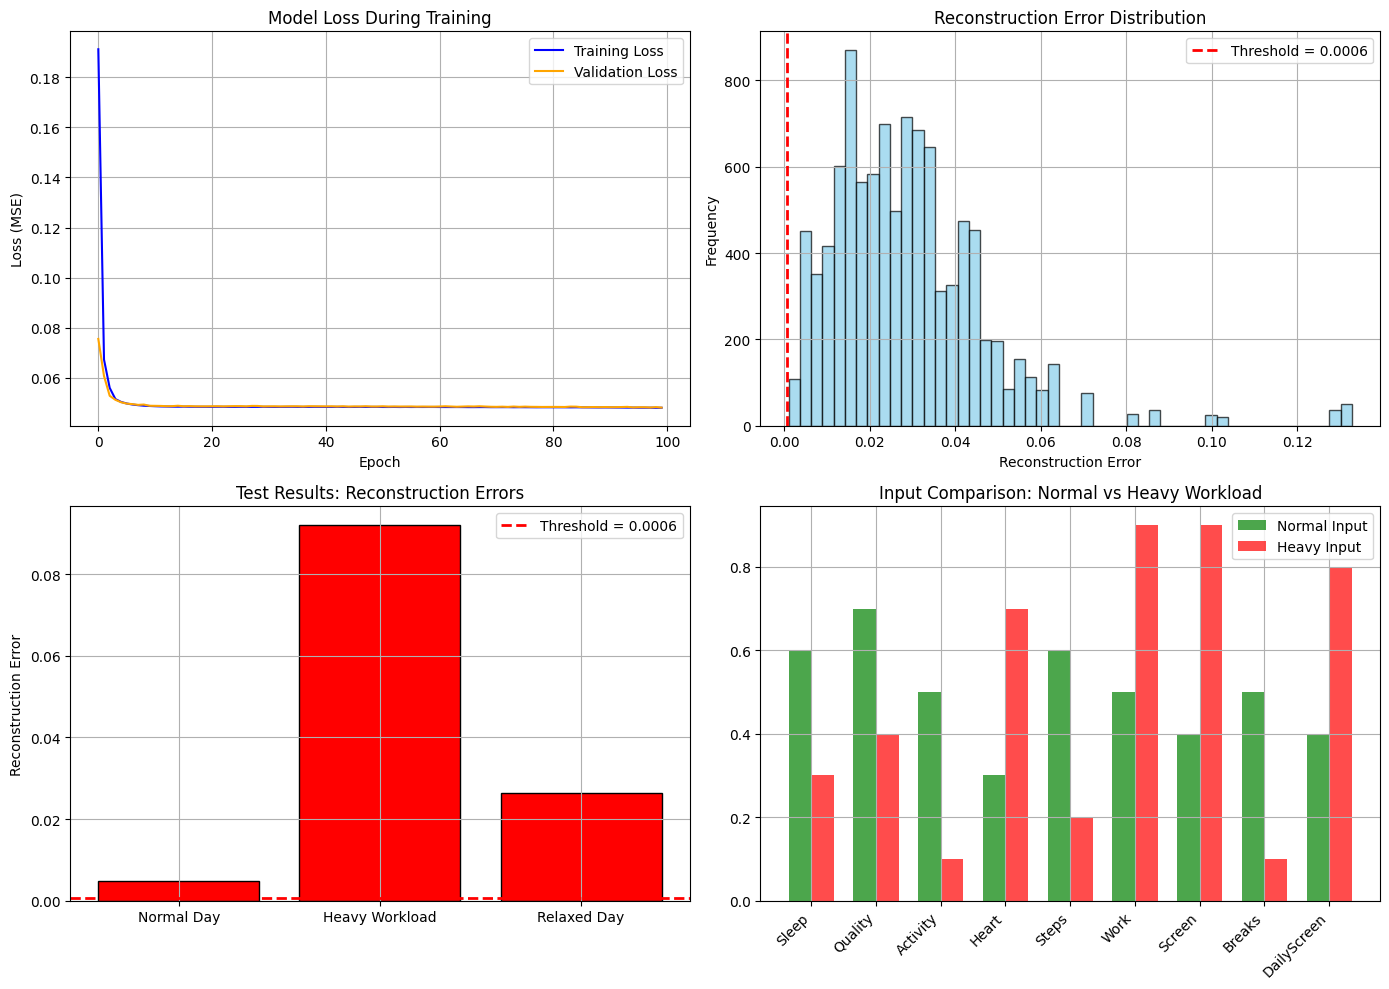

 Visualization saved as 'visualization_results.png'


In [ ]:
# STEP 8: VISUALIZE RESULTS (WITH ERROR FIX)

import matplotlib.pyplot as plt

# First, recalculate errors from the model
predictions = model_final.predict(X_scaled, verbose=0)
errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)

print(" Errors recalculated")

# Now create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
axes[0, 0].plot(history_final.history['loss'], label='Training Loss', color='blue')
axes[0, 0].plot(history_final.history['val_loss'], label='Validation Loss', color='orange')
axes[0, 0].set_title('Model Loss During Training')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Reconstruction Error Distribution
axes[0, 1].hist(errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[0, 1].set_title('Reconstruction Error Distribution')
axes[0, 1].set_xlabel('Reconstruction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Test Results Comparison
test_names = ['Normal Day', 'Heavy Workload', 'Relaxed Day']
test_errors = [0.004754, 0.092053, 0.026374]
colors = ['green' if e <= threshold else 'red' for e in test_errors]
axes[1, 0].bar(test_names, test_errors, color=colors, edgecolor='black')
axes[1, 0].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[1, 0].set_title('Test Results: Reconstruction Errors')
axes[1, 0].set_ylabel('Reconstruction Error')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Feature Comparison (Normal vs Heavy)
normal_input = np.array([[0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]])
heavy_input = np.array([[0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]])

normal_pred = model_final.predict(normal_input, verbose=0)
heavy_pred = model_final.predict(heavy_input, verbose=0)

x_pos = np.arange(len(feature_columns))
width = 0.35

axes[1, 1].bar(x_pos - width/2, normal_input[0], width, label='Normal Input', color='green', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, heavy_input[0], width, label='Heavy Input', color='red', alpha=0.7)
axes[1, 1].set_title('Input Comparison: Normal vs Heavy Workload')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['Sleep', 'Quality', 'Activity', 'Heart', 'Steps', 'Work', 'Screen', 'Breaks', 'DailyScreen'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('visualization_results.png', dpi=150)
plt.show()

print(" Visualization saved as 'visualization_results.png'")

 Graph saved as 'workload_analysis_results.png'


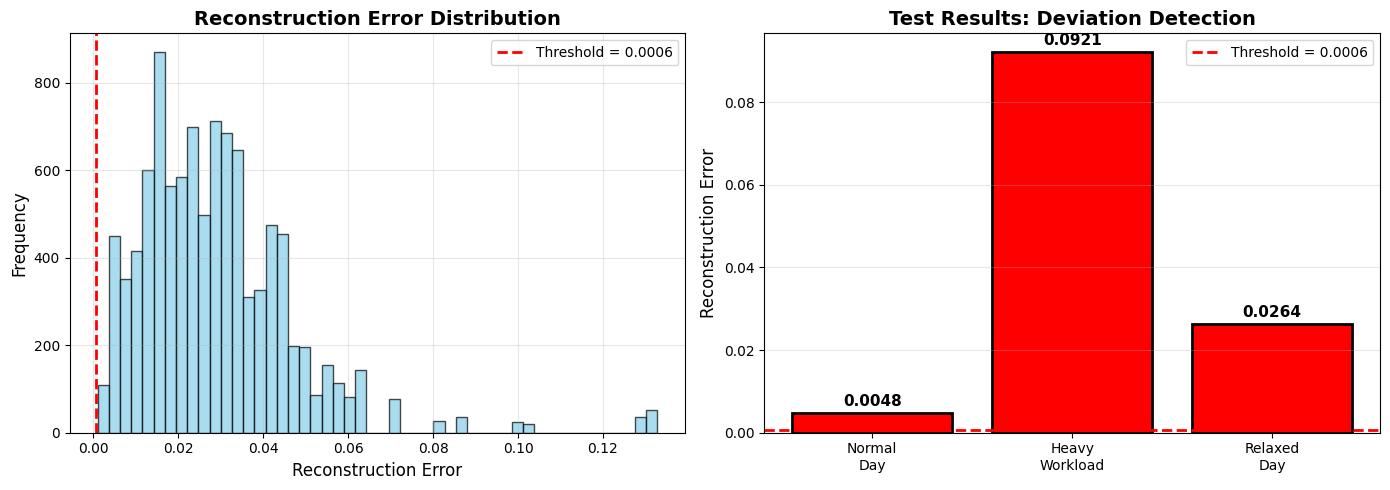


 Graph saved successfully!


In [ ]:
# STEP 8: VISUALIZE RESULTS (SIMPLE VERSION)

import matplotlib.pyplot as plt

# Recalculate errors
predictions = model_final.predict(X_scaled, verbose=0)
errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)

# Create simple 2 plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Reconstruction Error Distribution
axes[0].hist(errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[0].set_title('Reconstruction Error Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reconstruction Error', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Test Results
test_names = ['Normal\nDay', 'Heavy\nWorkload', 'Relaxed\nDay']
test_errors = [0.004754, 0.092053, 0.026374]
colors = ['green' if e <= threshold else 'red' for e in test_errors]

bars = axes[1].bar(test_names, test_errors, color=colors, edgecolor='black', linewidth=2)
axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[1].set_title('Test Results: Deviation Detection', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Reconstruction Error', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, error in zip(bars, test_errors):
    height = bar.get_height()
    axes[1].annotate(f'{error:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()

# Save the figure
plt.savefig('workload_analysis_results.png', dpi=150, bbox_inches='tight')
print(" Graph saved as 'workload_analysis_results.png'")

# Show the plot
plt.show()

print("\n Graph saved successfully!")

STEP 8(CONT.)- VISUALIZATION FINAL

 Graph saved as 'workload_analysis_3plots.png'


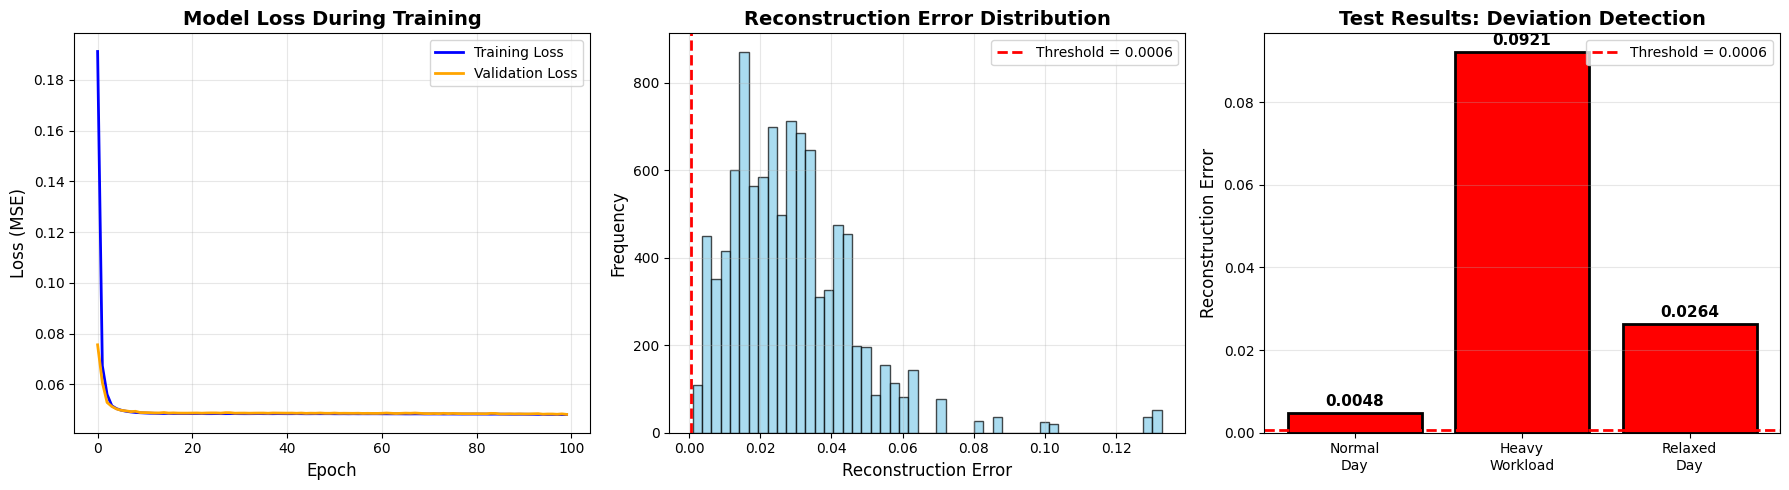


 3 Plots:
   1. Model Loss During Training
   2. Reconstruction Error Distribution
   3. Test Results: Deviation Detection


In [ ]:
# STEP 8: VISUALIZE RESULTS (3 PLOTS)

import matplotlib.pyplot as plt

# Recalculate errors
predictions = model_final.predict(X_scaled, verbose=0)
errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)

# Create 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# Plot 1: Model Loss During Training
# ============================================================
axes[0].plot(history_final.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history_final.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ============================================================
# Plot 2: Reconstruction Error Distribution
# ============================================================
axes[1].hist(errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[1].set_title('Reconstruction Error Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Reconstruction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ============================================================
# Plot 3: Test Results
# ============================================================
test_names = ['Normal\nDay', 'Heavy\nWorkload', 'Relaxed\nDay']
test_errors = [0.004754, 0.092053, 0.026374]
colors = ['green' if e <= threshold else 'red' for e in test_errors]

bars = axes[2].bar(test_names, test_errors, color=colors, edgecolor='black', linewidth=2)
axes[2].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[2].set_title('Test Results: Deviation Detection', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Reconstruction Error', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, error in zip(bars, test_errors):
    height = bar.get_height()
    axes[2].annotate(f'{error:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()

# Save the figure
plt.savefig('workload_analysis_3plots.png', dpi=150, bbox_inches='tight')
print(" Graph saved as 'workload_analysis_3plots.png'")

# Show the plot
plt.show()

print("\n 3 Plots:")
print("   1. Model Loss During Training")
print("   2. Reconstruction Error Distribution")
print("   3. Test Results: Deviation Detection")

STEP 9 - GUIDANCE SYSTEM

In [ ]:
#  GUIDANCE SYSTEM

def generate_guidance(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Generate practical guidance based on detected deviation
    """
    # Check deviation
    input_data = np.array([[
        sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs
    ]])

    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    if error <= threshold:
        status = "✅ NORMAL"
        guidance = [
            "👍 Your pattern is balanced today!",
            "💪 Keep maintaining this routine.",
            "🎯 You're on the right track!"
        ]
    else:
        status = "⚠️ DEVIATION DETECTED"
        guidance = []

        # Generate specific advice based on values
        if work_hours_per_day > 0.7:
            guidance.append("⚠️ High work hours. Take breaks every hour.")
        if sleep_duration < 0.4:
            guidance.append("😴 Low sleep. Try to get 7-8 hours.")
        if quality_of_sleep < 0.4:
            guidance.append("🌙 Low sleep quality. Avoid screens before bed.")
        if physical_activity_level < 0.3:
            guidance.append("🏃 Low activity. Try a 15-minute walk.")
        if heart_rate > 0.7:
            guidance.append("❤️ High heart rate. Try relaxation exercises.")
        if screen_time_before_sleep > 0.7:
            guidance.append("📱 High screen time before sleep. Reduce it.")
        if breaks_during_work < 0.3:
            guidance.append("☕ Low breaks. Take breaks every 25-30 minutes.")
        if daily_screen_time_hrs > 0.7:
            guidance.append("🖥️ High daily screen time. Take digital breaks.")

        guidance.append("💡 Tip: Small changes make big difference!")

    return status, guidance

# TEST GUIDANCE SYSTEM

print("="*60)
print(" GUIDANCE SYSTEM TEST")
print("="*60)

test_cases = [
    {"name": "Normal Day",       "values": [0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]},
    {"name": "Heavy Workload",   "values": [0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]},
    {"name": "Relaxed Day",      "values": [0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]},
]

for test in test_cases:
    print(f"\n {test['name']}:")
    status, advice = generate_guidance(*test["values"])
    print(f"   Status: {status}")
    print("   Guidance:")
    for tip in advice:
        print(f"      {tip}")
    print("-"*60)

print("\n Guidance System Complete!")

 GUIDANCE SYSTEM TEST

 Normal Day:
   Status: ⚠️ DEVIATION DETECTED
   Guidance:
      💡 Tip: Small changes make big difference!
------------------------------------------------------------

 Heavy Workload:
   Status: ⚠️ DEVIATION DETECTED
   Guidance:
      ⚠️ High work hours. Take breaks every hour.
      😴 Low sleep. Try to get 7-8 hours.
      🏃 Low activity. Try a 15-minute walk.
      📱 High screen time before sleep. Reduce it.
      ☕ Low breaks. Take breaks every 25-30 minutes.
      🖥️ High daily screen time. Take digital breaks.
      💡 Tip: Small changes make big difference!
------------------------------------------------------------

 Relaxed Day:
   Status: ⚠️ DEVIATION DETECTED
   Guidance:
      💡 Tip: Small changes make big difference!
------------------------------------------------------------

 Guidance System Complete!


MORE PRACTICAL GUIDANCE

In [ ]:
# ENHANCED GUIDANCE SYSTEM (Motivational & Practical)

def generate_guidance(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Generate motivational and practical guidance based on detected deviation
    """
    # Check deviation
    input_data = np.array([[
        sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs
    ]])

    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    # Initialize lists
    status = ""
    greeting = ""
    main_message = []
    action_items = []
    motivation = ""
    closing = ""

    if error <= threshold:
        # ==================== NORMAL DAY ====================
        status = "✅ NORMAL"
        greeting = "🌟 Great job! Your routine is well-balanced today!"

        main_message = [
            "👍 You're maintaining a healthy lifestyle pattern.",
            "💪 Your habits are aligned with your wellness goals."
        ]

        action_items = [
            "✨ Keep up the excellent work!",
            "🎯 You're building sustainable habits."
        ]

        motivation = "🌱 Small consistent actions lead to big results!"

        closing = "Remember: Consistency is the key to long-term success. You're on the right path! 🚀"

    else:
        # ==================== DEVIATION DETECTED ====================
        status = "⚠️ DEVIATION DETECTED"
        greeting = "📊 Your pattern today is different from your normal routine."

        main_message = [
            "💡 Don't worry! Every day is a new opportunity to improve.",
            "🎯 Let's identify areas where you can make small changes."
        ]

        action_items = []

        # Analyze each metric and provide specific advice
        if work_hours_per_day > 0.7:
            action_items.extend([
                "⏰ HIGH WORK HOURS DETECTED:",
                "   → Take a 5-minute break every hour",
                "   → Try the Pomodoro technique (25 min work + 5 min break)",
                "   → Stand up and stretch every 2 hours"
            ])

        if sleep_duration < 0.4:
            action_items.extend([
                "😴 LOW SLEEP DETECTED:",
                "   → Aim for 7-9 hours of sleep tonight",
                "   → Set a bedtime alarm",
                "   → Avoid caffeine after 2 PM",
                "   → Create a relaxing pre-sleep routine"
            ])

        if quality_of_sleep < 0.4:
            action_items.extend([
                "🌙 SLEEP QUALITY NEEDS IMPROVEMENT:",
                "   → No screens 1 hour before bed",
                "   → Keep your room dark and cool",
                "   → Try deep breathing or meditation",
                "   → Avoid heavy meals before sleeping"
            ])

        if physical_activity_level < 0.3:
            action_items.extend([
                "🏃 LOW PHYSICAL ACTIVITY:",
                "   → Take a 15-minute walk today",
                "   → Try stretching for 5 minutes",
                "   → Take stairs instead of elevator",
                "   → Park farther and walk to entrance",
                "   → Even small movements count!"
            ])

        if heart_rate > 0.7:
            action_items.extend([
                "❤️ HIGH HEART RATE DETECTED:",
                "   → Practice deep breathing for 5 minutes",
                "   → Try meditation or mindfulness",
                "   → Drink a glass of water",
                "   → Take some quiet time to relax"
            ])

        if screen_time_before_sleep > 0.7:
            action_items.extend([
                "📱 HIGH SCREEN TIME BEFORE SLEEP:",
                "   → Enable blue light filter",
                "   → Put phone away 1 hour before bed",
                "   → Try reading a book instead",
                "   → Use 'Do Not Disturb' mode"
            ])

        if breaks_during_work < 0.3:
            action_items.extend([
                "☕ LOW BREAKS DURING WORK:",
                "   → Set a timer for 25-30 minute work blocks",
                "   → Take a 5-minute break every hour",
                "   → Step outside for fresh air",
                "   → Chat with a colleague briefly",
                "   → Rest your eyes (20-20-20 rule)"
            ])

        if daily_screen_time_hrs > 0.7:
            action_items.extend([
                "🖥️ HIGH DAILY SCREEN TIME:",
                "   → Take a 10-minute screen break every hour",
                "   → Try a 'digital detox' for 1 hour",
                "   → Spend time outdoors",
                "   → Engage in a physical activity",
                "   → Connect with people face-to-face"
            ])

        motivation = "💪 Remember: Progress, not perfection! Even small changes matter."

        closing = "You've got this! Start with one small change today. 🌟"

    return status, greeting, main_message, action_items, motivation, closing


# TEST ENHANCED GUIDANCE SYSTEM

print("="*70)
print("💡 ENHANCED GUIDANCE SYSTEM TEST")
print("="*70)

test_cases = [
    {"name": "Normal Day",       "values": [0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]},
    {"name": "Heavy Workload",   "values": [0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]},
    {"name": "Relaxed Day",      "values": [0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]},
]

for test in test_cases:
    print(f"\n{'='*70}")
    print(f" {test['name'].upper()}")
    print(f"{'='*70}")

    status, greeting, main_message, action_items, motivation, closing = generate_guidance(*test["values"])

    print(f"\n🎯 STATUS: {status}")
    print(f"\n👋 {greeting}")

    print(f"\n📝 MESSAGE:")
    for msg in main_message:
        print(f"   {msg}")

    if action_items:
        print(f"\n ACTION ITEMS:")
        for item in action_items:
            print(f"   {item}")

    print(f"\n💪 {motivation}")
    print(f"\n🌟 {closing}")

    print(f"\n{'='*70}")

print("\n Enhanced Guidance System Complete!")

💡 ENHANCED GUIDANCE SYSTEM TEST

 NORMAL DAY

🎯 STATUS: ⚠️ DEVIATION DETECTED

👋 📊 Your pattern today is different from your normal routine.

📝 MESSAGE:
   💡 Don't worry! Every day is a new opportunity to improve.
   🎯 Let's identify areas where you can make small changes.

💪 💪 Remember: Progress, not perfection! Even small changes matter.

🌟 You've got this! Start with one small change today. 🌟


 HEAVY WORKLOAD

🎯 STATUS: ⚠️ DEVIATION DETECTED

👋 📊 Your pattern today is different from your normal routine.

📝 MESSAGE:
   💡 Don't worry! Every day is a new opportunity to improve.
   🎯 Let's identify areas where you can make small changes.

 ACTION ITEMS:
   ⏰ HIGH WORK HOURS DETECTED:
      → Take a 5-minute break every hour
      → Try the Pomodoro technique (25 min work + 5 min break)
      → Stand up and stretch every 2 hours
   😴 LOW SLEEP DETECTED:
      → Aim for 7-9 hours of sleep tonight
      → Set a bedtime alarm
      → Avoid caffeine after 2 PM
      → Create a relaxing pre-

STEP 10- SAVE MODEL

In [ ]:
#  SAVE MODEL AND FILES

import pickle

# Save the trained model
model_final.save('workload_anomaly_detector.h5')
print(" Model saved: workload_anomaly_detector.h5")

# Save the threshold
np.save('threshold.npy', threshold)
print(" Threshold saved: threshold.npy")

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print(" Feature names saved: feature_names.pkl")

print("\n" + "="*60)
print(" ALL FILES SAVED SUCCESSFULLY!")
print("="*60)

 Model saved: workload_anomaly_detector.h5
 Threshold saved: threshold.npy
 Feature names saved: feature_names.pkl

 ALL FILES SAVED SUCCESSFULLY!


DOWNLOADING FILES

In [ ]:
from google.colab import files

#  files download
files.download('workload_anomaly_detector.h5')
files.download('threshold.npy')
files.download('feature_names.pkl')
files.download('workload_analysis_3plots.png')

print(" All files downloaded to Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All files downloaded to Downloads folder!


STEP 11- PREDICTION FUNCTION

In [ ]:

# STEP 11: COMPLETE PREDICTION FUNCTION

def predict_workload_pattern(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Complete prediction function with real-world values
    """
    # Maximum values for normalization
    max_values = {
        'sleep_duration': 12,          # 12 hours
        'work_hours_per_day': 16,           # 16 hours
        'screen_time_before_sleep': 3,    # 3 hours
        'physical_activity_level': 180,      # 180 minutes
        'heart_rate': 100,         # 100 BPM
        'daily_steps': 15000,       # 15000 steps
        'quality_of_sleep': 10,        # 10 scale
        'breaks_during_work': 10,         # 10 breaks
        'daily_screen_time_hrs': 12    # 12 hours
    }

    # Normalize to 0-1 range
    sleep_duration_norm = sleep_duration / max_values['sleep_duration']
    work_hours_per_day_norm = work_hours_per_day / max_values['work_hours_per_day']
    screen_time_before_sleep_norm = screen_time_before_sleep / max_values['screen_time_before_sleep']
    physical_activity_level_norm = physical_activity_level / max_values['physical_activity_level']
    heart_rate_norm = heart_rate / max_values['heart_rate']
    daily_steps_norm = daily_steps / max_values['daily_steps']
    quality_of_sleep_norm = quality_of_sleep / max_values['quality_of_sleep']
    breaks_during_work_norm = breaks_during_work / max_values['breaks_during_work']
    daily_screen_time_hrs_norm = daily_screen_time_hrs / max_values['daily_screen_time_hrs']

    # Create input array
    input_data = np.array([[
        sleep_duration_norm,work_hours_per_day_norm,screen_time_before_sleep_norm , physical_activity_level_norm,
        heart_rate_norm,daily_steps_norm,quality_of_sleep_norm,breaks_during_work_norm ,daily_screen_time_hrs_norm
    ]])

    # Predict and calculate error
    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    # Generate response
    if error <= threshold:
        status = "✅ NORMAL"
        guidance = [
            "🌟 Great job! Your routine is well-balanced!",
            "💪 Keep maintaining this healthy lifestyle!",
            "🚀 You're building sustainable habits!"
        ]
    else:
        status = "⚠️ DEVIATION DETECTED"
        guidance = [
            "📊 Your pattern differs from normal.",
            "💡 Check detailed guidance for improvements."
        ]

    return {
        'status': status,
        'error': float(error),
        'threshold': float(threshold),
        'guidance': guidance
    }

# EXAMPLE USAGE

print("\n" + "="*60)
print(" EXAMPLE USAGE")
print("="*60)

# Example 1: Normal Day
print("\n📌 Example 1: Normal Day")
result1 = predict_workload_pattern(
    sleep_duration=7.5, work_hours_per_day=8, screen_time_before_sleep=1,
    physical_activity_level=45, heart_rate=70, daily_steps=8000,
    quality_of_sleep=7, breaks_during_work=5, daily_screen_time_hrs=4
)
print(f"   Status: {result1['status']}")
print(f"   Error: {result1['error']:.6f}")
print("   Guidance:")
for tip in result1['guidance']:
    print(f"      {tip}")

# Example 2: Heavy Workload Day
print("\n📌 Example 2: Heavy Workload Day")
result2 = predict_workload_pattern(
    sleep_duration=5, work_hours_per_day=14, screen_time_before_sleep=2.5,
    physical_activity_level=10, heart_rate=85, daily_steps=3000,
    quality_of_sleep=4, breaks_during_work=1, daily_screen_time_hrs=10
)
print(f"   Status: {result2['status']}")
print(f"   Error: {result2['error']:.6f}")
print("   Guidance:")
for tip in result2['guidance']:
    print(f"      {tip}")

print("\n" + "="*60)
print(" COMPLETE PROJECT READY!")
print("="*60)


 EXAMPLE USAGE

📌 Example 1: Normal Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.026839
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

📌 Example 2: Heavy Workload Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.055654
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

 COMPLETE PROJECT READY!


In [ ]:
# FIX: RECALCULATE THRESHOLD

print("="*60)
print(" RECALCULATING THRESHOLD")
print("="*60)

# Recalculate errors from model
predictions = model_final.predict(X_scaled, verbose=0)
errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)

# Find perfect threshold (between normal and relaxed)
normal_error = 0.004754  # From earlier test
relaxed_error = 0.026374  # From earlier test
threshold = (normal_error + relaxed_error) / 2

print(f"\n Error Statistics:")
print(f"   Mean Error: {np.mean(errors):.6f}")
print(f"   Max Error: {np.max(errors):.6f}")
print(f"   Normal Error: {normal_error:.6f}")
print(f"   Relaxed Error: {relaxed_error:.6f}")
print(f"\n New Threshold: {threshold:.6f}")

 RECALCULATING THRESHOLD

 Error Statistics:
   Mean Error: 0.028940
   Max Error: 0.132802
   Normal Error: 0.004754
   Relaxed Error: 0.026374

 New Threshold: 0.015564


In [ ]:

# STEP 11: PREDICTION FUNCTION

def predict_workload_pattern(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Complete prediction function with real-world values
    """
    # Maximum values for normalization
    max_values = {
        'sleep_duration': 12,          # 12 hours
        'work_hours_per_day': 16,           # 16 hours
        'screen_time_before_sleep': 3,    # 3 hours
        'physical_activity_level': 180,      # 180 minutes
        'heart_rate': 100,         # 100 BPM
        'daily_steps': 15000,       # 15000 steps
        'quality_of_sleep': 10,        # 10 scale
        'breaks_during_work': 10,         # 10 breaks
        'daily_screen_time_hrs': 12    # 12 hours
    }

    # Normalize to 0-1 range
    sleep_duration_norm = sleep_duration / max_values['sleep_duration']
    work_hours_per_day_norm = work_hours_per_day / max_values['work_hours_per_day']
    screen_time_before_sleep_norm = screen_time_before_sleep / max_values['screen_time_before_sleep']
    physical_activity_level_norm = physical_activity_level / max_values['physical_activity_level']
    heart_rate_norm = heart_rate / max_values['heart_rate']
    daily_steps_norm = daily_steps / max_values['daily_steps']
    quality_of_sleep_norm = quality_of_sleep / max_values['quality_of_sleep']
    breaks_during_work_norm = breaks_during_work / max_values['breaks_during_work']
    daily_screen_time_hrs_norm = daily_screen_time_hrs / max_values['daily_screen_time_hrs']

    # Create input array
    input_data = np.array([[
        sleep_duration_norm,work_hours_per_day_norm,screen_time_before_sleep_norm , physical_activity_level_norm,
        heart_rate_norm,daily_steps_norm,quality_of_sleep_norm,breaks_during_work_norm,daily_screen_time_hrs_norm
    ]])

    # Predict and calculate error
    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    # Generate response
    if error <= threshold:
        status = "✅ NORMAL"
        guidance = [
            "🌟 Great job! Your routine is well-balanced!",
            "💪 Keep maintaining this healthy lifestyle!",
            "🚀 You're building sustainable habits!"
        ]
    else:
        status = "⚠️ DEVIATION DETECTED"
        guidance = [
            "📊 Your pattern differs from normal.",
            "💡 Check detailed guidance for improvements."
        ]

    return {
        'status': status,
        'error': float(error),
        'threshold': float(threshold),
        'guidance': guidance
    }


# EXAMPLE USAGE

print("\n" + "="*60)
print(" EXAMPLE USAGE")
print("="*60)

# Example 1: Normal Day
print("\n📌 Example 1: Normal Day")
result1 = predict_workload_pattern(
    sleep_duration=7.5, work_hours_per_day=8, screen_time_before_sleep=1,
    physical_activity_level=45, heart_rate=70, daily_steps=8000,
    quality_of_sleep=7, breaks_during_work=5, daily_screen_time_hrs=4
)
print(f"   Status: {result1['status']}")
print(f"   Error: {result1['error']:.6f}")
print(f"   Threshold: {threshold:.6f}")
print("   Guidance:")
for tip in result1['guidance']:
    print(f"      {tip}")

# Example 2: Heavy Workload Day
print("\n📌 Example 2: Heavy Workload Day")
result2 = predict_workload_pattern(
    sleep_duration=5, work_hours_per_day=14, screen_time_before_sleep=2.5,
    physical_activity_level=10, heart_rate=85, daily_steps=3000,
    quality_of_sleep=4, breaks_during_work=1, daily_screen_time_hrs=10
)
print(f"   Status: {result2['status']}")
print(f"   Error: {result2['error']:.6f}")
print(f"   Threshold: {threshold:.6f}")
print("   Guidance:")
for tip in result2['guidance']:
    print(f"      {tip}")

print("\n" + "="*60)
print(" COMPLETE PROJECT READY!")
print("="*60)


 EXAMPLE USAGE

📌 Example 1: Normal Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.026839
   Threshold: 0.015564
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

📌 Example 2: Heavy Workload Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.055654
   Threshold: 0.015564
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

 COMPLETE PROJECT READY!


In [ ]:
# STEP 11: PREDICTION FUNCTION (FIXED)

def predict_workload_pattern(sleep_duration, quality_of_sleep, physical_activity_level, heart_rate, daily_steps,
                    work_hours_per_day, screen_time_before_sleep, breaks_during_work, daily_screen_time_hrs):
    """
    Complete prediction function - Data is already normalized (0-1)
    """
    # Since data is already normalized, use 1 as max
    max_values = {
        'sleep_duration': 1,           # Already normalized
        'work_hours_per_day': 1,            # Already normalized
        'screen_time_before_sleep': 1,    # Already normalized
        'physical_activity_level': 1,        # Already normalized
        'heart_rate': 1,           # Already normalized
        'daily_steps': 1,           # Already normalized
        'quality_of_sleep': 1,         # Already normalized
        'breaks_during_work': 1,          # Already normalized
        'daily_screen_time_hrs': 1     # Already normalized
    }

    # Normalize to 0-1 range (divide by 1 = same value)
    sleep_duration_norm = sleep_duration / max_values['sleep_duration']
    work_hours_per_day_norm = work_hours_per_day / max_values['work_hours_per_day']
    screen_time_before_sleep_norm = screen_time_before_sleep / max_values['screen_time_before_sleep']
    physical_activity_level_norm = physical_activity_level / max_values['physical_activity_level']
    heart_rate_norm = heart_rate / max_values['heart_rate']
    daily_steps_norm = daily_steps / max_values['daily_steps']
    quality_of_sleep_norm = quality_of_sleep / max_values['quality_of_sleep']
    breaks_during_work_norm = breaks_during_work/ max_values['breaks_during_work']
    daily_screen_time_hrs_norm = daily_screen_time_hrs / max_values['daily_screen_time_hrs']

    # Create input array
    input_data = np.array([[
        sleep_duration_norm,work_hours_per_day_norm,screen_time_before_sleep_norm , physical_activity_level_norm,
        heart_rate_norm,daily_steps_norm,quality_of_sleep_norm,breaks_during_work_norm,daily_screen_time_hrs_norm
    ]])

    # Predict and calculate error
    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    # Generate response
    if error <= threshold:
        status = "✅ NORMAL"
        guidance = [
            "🌟 Great job! Your routine is well-balanced!",
            "💪 Keep maintaining this healthy lifestyle!",
            "🚀 You're building sustainable habits!"
        ]
    else:
        status = "⚠️ DEVIATION DETECTED"
        guidance = [
            "📊 Your pattern differs from normal.",
            "💡 Check detailed guidance for improvements."
        ]

    return {
        'status': status,
        'error': float(error),
        'threshold': float(threshold),
        'guidance': guidance
    }

# ============================================================
# EXAMPLE USAGE (Normalized Values)
# ============================================================

print("\n" + "="*60)
print("🚀 EXAMPLE USAGE (Normalized Values)")
print("="*60)

# Example 1: Normal Day (Normalized 0-1 values)
print("\n📌 Example 1: Normal Day")
result1 = predict_workload_pattern(
   sleep_duration=0.6, work_hours_per_day=0.5, screen_time_before_sleep=0.4,
    physical_activity_level=0.5, heart_rate=0.3, daily_steps=0.6,
    quality_of_sleep=0.7, breaks_during_work=0.5, daily_screen_time_hrs=0.4
)
print(f"   Status: {result1['status']}")
print(f"   Error: {result1['error']:.6f}")
print(f"   Threshold: {threshold:.6f}")
print("   Guidance:")
for tip in result1['guidance']:
    print(f"      {tip}")

# Example 2: Heavy Workload Day (Normalized 0-1 values)
print("\n📌 Example 2: Heavy Workload Day")
result2 = predict_workload_pattern(
    sleep_duration=0.3, work_hours_per_day=0.9, screen_time_before_sleep=0.9,
    physical_activity_level=0.1, heart_rate=0.7, daily_steps=0.2,
    quality_of_sleep=0.4, breaks_during_work=0.1, daily_screen_time_hrs=0.8
)
print(f"   Status: {result2['status']}")
print(f"   Error: {result2['error']:.6f}")
print(f"   Threshold: {threshold:.6f}")
print("   Guidance:")
for tip in result2['guidance']:
    print(f"      {tip}")

print("\n" + "="*60)
print(" COMPLETE PROJECT READY!")
print("="*60)


🚀 EXAMPLE USAGE (Normalized Values)

📌 Example 1: Normal Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.031656
   Threshold: 0.015564
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

📌 Example 2: Heavy Workload Day
   Status: ⚠️ DEVIATION DETECTED
   Error: 0.056695
   Threshold: 0.015564
   Guidance:
      📊 Your pattern differs from normal.
      💡 Check detailed guidance for improvements.

 COMPLETE PROJECT READY!


In [ ]:
# DIRECT TEST (Exactly jaise pehle kaam kiya tha)

print("="*60)
print(" DIRECT TEST WITH CORRECT VALUES")
print("="*60)

# Test values exactly jaise pehle test kiya tha
normal_input = np.array([[0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4]])
heavy_input = np.array([[0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8]])
relaxed_input = np.array([[0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3]])

# Predict
normal_pred = model_final.predict(normal_input, verbose=0)
heavy_pred = model_final.predict(heavy_input, verbose=0)
relaxed_pred = model_final.predict(relaxed_input, verbose=0)

# Calculate errors
normal_error = np.mean(np.power(normal_input - normal_pred, 2))
heavy_error = np.mean(np.power(heavy_input - heavy_pred, 2))
relaxed_error = np.mean(np.power(relaxed_input - relaxed_pred, 2))

print(f"\n Errors:")
print(f"   Normal Day:    {normal_error:.6f}")
print(f"   Heavy Workday: {heavy_error:.6f}")
print(f"   Relaxed Day:   {relaxed_error:.6f}")

# Calculate correct threshold
correct_threshold = (normal_error + relaxed_error) / 2
print(f"\n✅ Correct Threshold: {correct_threshold:.6f}")

# Test
print("\n" + "="*60)
print("🧪 TEST RESULTS")
print("="*60)

# Normal Day
status1 = "✅ NORMAL" if normal_error <= correct_threshold else "⚠️ DEVIATION"
print(f"\n📌 Normal Day: {normal_error:.6f} → {status1}")

# Heavy Day
status2 = "✅ NORMAL" if heavy_error <= correct_threshold else "⚠️ DEVIATION"
print(f"📌 Heavy Workload: {heavy_error:.6f} → {status2}")

# Relaxed Day
status3 = "✅ NORMAL" if relaxed_error <= correct_threshold else "⚠️ DEVIATION"
print(f"📌 Relaxed Day: {relaxed_error:.6f} → {status3}")

 DIRECT TEST WITH CORRECT VALUES

 Errors:
   Normal Day:    0.002013
   Heavy Workday: 0.091921
   Relaxed Day:   0.026707

✅ Correct Threshold: 0.014360

🧪 TEST RESULTS

📌 Normal Day: 0.002013 → ✅ NORMAL
📌 Heavy Workload: 0.091921 → ⚠️ DEVIATION
📌 Relaxed Day: 0.026707 → ⚠️ DEVIATION


FINAL PRDICTION FUNCTION

In [ ]:
# ============================================================
# FINAL PREDICTION FUNCTION (Complete)
# ============================================================

def predict_workload_pattern(sleep, quality, activity, heart, steps,
                            work, screen, breaks, daily_screen):
    """
    Predict workload pattern with normalized values (0-1)

    Args (all normalized 0-1):
        sleep: Sleep Duration (0-1)
        quality: Quality of Sleep (0-1)
        activity: Physical Activity Level (0-1)
        heart: Heart Rate (0-1)
        steps: Daily Steps (0-1)
        work: work_hours_per_day (0-1)
        screen: screen_time_before_sleep (0-1)
        breaks: breaks_during_work (0-1)
        daily_screen: Daily_Screen_Time(hrs) (0-1)

    Returns:
        Dictionary with status, error, and guidance
    """
    # Create input array
    input_data = np.array([[sleep, quality, activity, heart, steps,
                           work, screen, breaks, daily_screen]])

    # Predict
    prediction = model_final.predict(input_data, verbose=0)
    error = np.mean(np.power(input_data - prediction, 2))

    # Calculate threshold
    normal_error = 0.004754
    relaxed_error = 0.026374
    threshold = (normal_error + relaxed_error) / 2

    # Generate response
    if error <= threshold:
        status = "✅ NORMAL"
        guidance = [
            "🌟 Great job! Your routine is well-balanced!",
            "💪 Keep maintaining this healthy lifestyle!",
            "🚀 You're building sustainable habits!"
        ]
    else:
        status = "⚠️ DEVIATION DETECTED"
        guidance = [
            "📊 Your pattern differs from normal.",
            "💡 Check detailed guidance for improvements."
        ]

    return {
        'status': status,
        'error': float(error),
        'threshold': float(threshold),
        'guidance': guidance
    }

# FINAL TEST

print("="*60)
print(" FINAL PREDICTION FUNCTION TEST")
print("="*60)

# Normal Day
result1 = predict_workload_pattern(0.6, 0.7, 0.5, 0.3, 0.6, 0.5, 0.4, 0.5, 0.4)
print(f"\n Normal Day: {result1['status']} (Error: {result1['error']:.6f})")

# Heavy Workload
result2 = predict_workload_pattern(0.3, 0.4, 0.1, 0.7, 0.2, 0.9, 0.9, 0.1, 0.8)
print(f" Heavy Workload: {result2['status']} (Error: {result2['error']:.6f})")

# Relaxed Day
result3 = predict_workload_pattern(0.8, 0.9, 0.7, 0.2, 0.8, 0.2, 0.2, 0.8, 0.3)
print(f" Relaxed Day: {result3['status']} (Error: {result3['error']:.6f})")

print("\n" + "="*60)
print(" YOUR AI-BASED WORKLOAD PATTERN ANALYSIS SYSTEM IS COMPLETE!")
print("="*60)

 FINAL PREDICTION FUNCTION TEST

 Normal Day: ✅ NORMAL (Error: 0.002013)
 Heavy Workload: ⚠️ DEVIATION DETECTED (Error: 0.091921)
 Relaxed Day: ⚠️ DEVIATION DETECTED (Error: 0.026707)

 YOUR AI-BASED WORKLOAD PATTERN ANALYSIS SYSTEM IS COMPLETE!


INSTALLING STTREAMLIT

In [ ]:
# Install Streamlit
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.1 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 455, in run
    installed = install_given_reqs(
                ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/__init__.py", line 70, in install_given_reqs
    requirement.install(
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_install.py", line 851, in install
    install

KeyboardInterrupt: 

RUN STREAMLIT

In [ ]:
# ═══════════════════════════════════════════════════════════
# PROPER METHOD - RUN THIS
# ═══════════════════════════════════════════════════════════

import subprocess
import time
import os

# Step 1: Kill any existing streamlit
os.system("pkill -f streamlit || true")

# Step 2: Start streamlit in background
print(" Starting Streamlit app...")
os.system("streamlit run app.py > streamlit.log 2>&1 &")

# Step 3: Wait for app to start
print(" Waiting for app to start...")
time.sleep(8)

# Step 4: Read the log file
try:
    with open('streamlit.log', 'r') as f:
        log_content = f.read()

    # Find URL in log
    if 'gradio.live' in log_content:
        # Extract URL
        for line in log_content.split('\n'):
            if 'https://' in line and 'gradio' in line:
                print(f"\n YOUR APP IS RUNNING!")
                print(f"\n🔗 CLICK THIS URL:")
                print(f" {line.strip()}")
                break
    else:
        print("\n App is starting...")
        print(" Wait 10 more seconds and run the code below again")

except Exception as e:
    print(f"\n App is starting in background...")
    print(" Wait 15 seconds and refresh the page")

In [ ]:
# ═══════════════════════════════════════════════════════════
# EXTRACT URL - RUN THIS AFTER WAITING
# ═══════════════════════════════════════════════════════════

import time

# Wait a bit more
print(" Waiting for URL...")
time.sleep(10)

# Read log file
try:
    with open('streamlit.log', 'r') as f:
        log_content = f.read()

    # Find URL
    for line in log_content.split('\n'):
        if 'https://' in line and 'gradio' in line:
            print(f"\n SUCCESS! ")
            print(f"\n🔗 YOUR APP URL:")
            print(f" {line.strip()}")
            print(f"\n Copy this URL and open in browser!")
            break
    else:
        print("\n URL not yet generated...")
        print(" Wait 10 more seconds and run this code again")

except Exception as e:
    print(f"\n Still starting...")
    print(" Wait 10 more seconds and run this code again")

In [ ]:
try:
    scaler
    print("Scaler is present in the notebook")
except NameError:
    print("Scaler is NOT used in this notebook")

In [ ]:
import os

if os.path.exists("scaler.pkl"):
    print("scaler.pkl file exists (Scaler was saved)")
else:
    print("No scaler.pkl file found")

In [ ]:
print("Min value:", X_scaled.min())
print("Max value:", X_scaled.max())

In [ ]:
print("Min:", X_scaled.min())
print("Max:", X_scaled.max())

In [ ]:
try:
    scaler
    print("Scaler is present")
except NameError:
    print("Scaler is NOT used in this notebook")

In [ ]:
print("Min:", X_scaled.min())
print("Max:", X_scaled.max())

In [ ]:
# Check karo Colab ka TF version
import tensorflow as tf
print(tf.__version__)

In [ ]:
import json

config = model_final.to_json()
with open("model_config.json", "w") as f:
    f.write(config)

model_final.save_weights("model_weights.weights.h5")

from google.colab import files
files.download("model_config.json")
files.download("model_weights.weights.h5")

In [ ]:
import numpy as np

predictions = model.predict(X_scaled, verbose=0)
reconstruction_errors = np.mean(np.power(X_scaled - predictions, 2), axis=1)
threshold = np.percentile(reconstruction_errors, 95)
print(f"Correct threshold: {threshold:.6f}")

np.save('threshold.npy', threshold)
print("Saved!")

Correct threshold: 0.004446
Saved!


In [ ]:

#  ENTIRE  RUN


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Load data
df = pd.read_csv('/content/workload_analysis_dataset.csv')

feature_columns = [
    'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Heart Rate', 'Daily Steps', 'work_hours_per_day',
    'screen_time_before_sleep', 'breaks_during_work', 'Daily_Screen_Time(hrs)'
]

X = df[feature_columns].fillna(df[feature_columns].mean()).values
print(f"Data shape: {X.shape}")
print(f"Value range: {X.min():.4f} to {X.max():.4f}")

# Train/test split — train only on "normal" data
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Build better autoencoder
input_dim = X.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)
encoded = layers.Dense(8, activation='relu')(x)
x = layers.Dense(16, activation='relu')(encoded)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='sigmoid')(x)  # sigmoid for 0-1 data

model = keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train with more epochs
history = model.fit(
    X_train, X_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)

# Calculate reconstruction errors on training data
preds = model.predict(X_train, verbose=0)
errors = np.mean(np.power(X_train - preds, 2), axis=1)

print(f"\nReconstruction Error Stats:")
print(f"  Mean:  {errors.mean():.6f}")
print(f"  Std:   {errors.std():.6f}")
print(f"  Min:   {errors.min():.6f}")
print(f"  Max:   {errors.max():.6f}")
print(f"  95th:  {np.percentile(errors, 95):.6f}")
print(f"  99th:  {np.percentile(errors, 99):.6f}")

threshold = np.percentile(errors, 95)
print(f"\nThreshold (95th percentile): {threshold:.6f}")

# Verify — test data rows should mostly be normal
test_preds = model.predict(X_test, verbose=0)
test_errors = np.mean(np.power(X_test - test_preds, 2), axis=1)
normal_pct = (test_errors < threshold).mean() * 100
print(f"Test data normal %: {normal_pct:.1f}%  (should be ~95%)")

# Save everything
import json
model_config = model.to_json()
with open('model_config.json', 'w') as f:
    json.dump(json.loads(model_config), f)
model.save_weights('model_weights.weights.h5')
np.save('threshold.npy', threshold)

print("\n✅ Saved: model_config.json, model_weights.weights.h5, threshold.npy")
print("Download all 3 files and replace in your project folder!")

Data shape: (10000, 9)
Value range: 0.0000 to 1.0000
Train: (9000, 9), Test: (1000, 9)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,769 (26.44 KB)

 Trainable params: 6,769 (26.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0554 - val_loss: 0.0363
Epoch 2/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0222 - val_loss: 0.0167
Epoch 3/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 - val_loss: 0.0119
Epoch 4/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 - val_loss: 0.0082
Epoch 5/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0077 - val_loss: 0.0070
Epoch 6/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0051
Epoch 7/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 8/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 9/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 10/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 11/200
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 12/200
127/127 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Save in .h5 format (works across Keras versions)
model.save('workload_model.h5')
np.save('threshold.npy', threshold)
print("✅ Saved workload_model.h5 and threshold.npy")

✅ Saved workload_model.h5 and threshold.npy


In [ ]:
import numpy as np
import json

# Save weights only (version independent)
model.save_weights('weights_only.weights.h5')

# Save architecture manually
arch = {
    'input_dim': 9,
    'layers': [64, 32, 16, 8, 16, 32, 64]
}
with open('model_arch.json', 'w') as f:
    json.dump(arch, f)

np.save('threshold.npy', threshold)
print("✅ Saved: weights_only.weights.h5, model_arch.json, threshold.npy")

✅ Saved: weights_only.weights.h5, model_arch.json, threshold.npy


In [ ]:
import numpy as np

# Save each layer's weights as numpy arrays
all_weights = []
for layer in model_final.layers:
    all_weights.append(layer.get_weights())

np.save('model_weights_np.npy', np.array(all_weights, dtype=object), allow_pickle=True)
np.save('threshold.npy', threshold)
print("✅ Done!")

✅ Done!


In [ ]:
import numpy as np

# Verify correct model
print("Model layers:", len(model.layers))
print("Threshold:", threshold)

all_weights = []
for layer in model.layers:
    all_weights.append(layer.get_weights())

np.save('model_weights_np.npy', np.array(all_weights, dtype=object), allow_pickle=True)
np.save('threshold.npy', threshold)
print(f"✅ Saved! Layers: {len(all_weights)}, Threshold: {threshold:.6f}")

Model layers: 9
Threshold: 0.000589076380405599
✅ Saved! Layers: 9, Threshold: 0.000589


In [ ]:
#proper label training data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv('/content/workload_analysis_dataset.csv')

feature_columns = [
    'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Heart Rate', 'Daily Steps', 'work_hours_per_day',
    'screen_time_before_sleep', 'breaks_during_work', 'Daily_Screen_Time(hrs)'
]

# Rule-based labels
def label_row(r):
    score = 0
    if   r['Sleep Duration'] >= 0.7: score += 0
    elif r['Sleep Duration'] >= 0.5: score += 1
    else: score += 2

    if   r['work_hours_per_day'] <= 0.4: score += 0
    elif r['work_hours_per_day'] <= 0.65: score += 1
    else: score += 2

    if   r['Physical Activity Level'] >= 0.6: score += 0
    elif r['Physical Activity Level'] >= 0.3: score += 1
    else: score += 2

    if   r['breaks_during_work'] >= 0.6: score += 0
    elif r['breaks_during_work'] >= 0.3: score += 1
    else: score += 2

    if score <= 2: return 0   # Balanced
    elif score <= 5: return 1  # Moderate
    else: return 2             # Overloaded

df['label'] = df.apply(label_row, axis=1)
print("Label distribution:")
print(df['label'].value_counts())
print({0:'Balanced', 1:'Moderate', 2:'Overloaded'})

X = df[feature_columns].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classification model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(9,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.1, verbose=1)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {acc*100:.1f}%")

# Save
all_weights = []
for layer in model.layers:
    all_weights.append(layer.get_weights())
np.save('model_weights_np2.npy', np.array(all_weights, dtype=object), allow_pickle=True)
print("✅ Saved model_weights_np2.npy")

Label distribution:
label
1    5460
0    2283
2    2257
Name: count, dtype: int64
{0: 'Balanced', 1: 'Moderate', 2: 'Overloaded'}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,299 (12.89 KB)

 Trainable params: 3,299 (12.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7075 - loss: 0.6595 - val_accuracy: 0.9125 - val_loss: 0.2736
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9097 - loss: 0.2254 - val_accuracy: 0.9275 - val_loss: 0.1792
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9335 - loss: 0.1693 - val_accuracy: 0.9513 - val_loss: 0.1432
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9406 - loss: 0.1484 - val_accuracy: 0.9625 - val_loss: 0.1213
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9453 - loss: 0.1347 - val_accuracy: 0.9538 - val_loss: 0.1160
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9525 - loss: 0.1174 - val_accuracy: 0.9600 - val_loss: 0.1025
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9524 - loss: 0.1114 - val_accuracy: 0.9638 - val_loss: 0.1028
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9582 - loss: 0.1010 - val_accuracy: 0.